## Does Money Buy Movie Success?
This project looks at 7,668 films (1980–2020) to answer: does higher budget translate 
into better quality (IMDb score) and better financial return (ROI)? I explore spending 
patterns, profitability, and audience reception to find out.

In [68]:
# Importing Libraries useful the project
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [69]:
# Standard look and style for Visulizatin at once
sns.set_theme(style="whitegrid", font_scale=1.05)

plt.rcParams["figure.figsize"]      = (11, 6.5)
plt.rcParams["figure.facecolor"]    = "#FAFAF8"
plt.rcParams["axes.facecolor"]      = "#FAFAF8"
plt.rcParams["axes.titleweight"]    = "bold"
plt.rcParams["axes.titlesize"]      = 18
plt.rcParams["axes.titlepad"]       = 16
plt.rcParams["axes.labelsize"]      = 13
plt.rcParams["axes.labelweight"]    = "medium"
plt.rcParams["axes.spines.top"]     = False
plt.rcParams["axes.spines.right"]   = False
plt.rcParams["grid.linewidth"]      = 0.6
plt.rcParams["grid.alpha"]          = 0.4
plt.rcParams["xtick.labelsize"]     = 11
plt.rcParams["ytick.labelsize"]     = 11
plt.rcParams["legend.fontsize"]     = 11
plt.rcParams["legend.frameon"]      = False
plt.rcParams["savefig.dpi"]         = 200
plt.rcParams["savefig.bbox"]        = "tight"
plt.rcParams["savefig.facecolor"]   = "#FAFAF8"

sns.set_palette(["#3B82C4", "#E8734A", "#2FA88A", "#C0475C", "#8E6DC0",
                  "#D9A441", "#4E9A8C", "#B4574F"])

In [71]:
#Importing Dataset
df=pd.read_csv(r"C:\Users\Admin\Downloads\IMDB (1980-2020).csv")
df.isna().sum()

name           0
rating        77
genre          0
year           0
released       2
score          3
votes          3
director       0
writer         3
star           1
country        3
budget      2171
gross        189
company       17
runtime        4
dtype: int64

In [72]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7668 non-null   str    
 1   rating    7591 non-null   str    
 2   genre     7668 non-null   str    
 3   year      7668 non-null   int64  
 4   released  7666 non-null   str    
 5   score     7665 non-null   float64
 6   votes     7665 non-null   float64
 7   director  7668 non-null   str    
 8   writer    7665 non-null   str    
 9   star      7667 non-null   str    
 10  country   7665 non-null   str    
 11  budget    5497 non-null   float64
 12  gross     7479 non-null   float64
 13  company   7651 non-null   str    
 14  runtime   7664 non-null   float64
dtypes: float64(5), int64(1), str(9)
memory usage: 898.7 KB


### First Look
7,668 rows, 15 columns. `budget` is the most incomplete field (2,171 missing / 28%) — 
this is expected for older/smaller films where budget was never publicly disclosed. 
`gross` (189 missing), `runtime` (4), `company` (17) are minor gaps. I'll handle budget 
carefully since it drives most of the financial analysis later.

In [35]:
# AS there are some inconsistencies in the country mentioned in the release column and the country column itself
# Lets extract country from released column and drop country column
df=df.drop(columns='country')
df['Release_date']=df['released'].str.extract(r'^(.*?)\s*\(')
df['Country']=df['released'].str.extract(r'\((.*?)\)')
# Now drop Released column
df=df.drop(columns='released')


In [36]:
df.head(2)

,name,rating,genre,year,score,votes,director,writer,star,budget,gross,company,runtime,Release_date,Country
0,The Shining,R,Drama,1980,8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,19000000.0,46998772.0,Warner Bros.,146.0,"June 13, 1980",United States
1,The Blue Lagoon,R,Adventure,1980,5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,4500000.0,58853106.0,Columbia Pictures,104.0,"July 2, 1980",United States


In [37]:
# Sandardized ratig system
df['rating']=df['rating'].fillna('Not Rated')
rating_map = {
    'TV-PG': 'PG',
    'TV-14': 'PG-13',
    'TV-MA': 'R',
    'Unrated': 'Not Rated',
    'Approved': 'G',
    'X': 'NC-17'
}

df['rating'] = df['rating'].replace(rating_map)

                    

In [38]:
df['rating'].unique()


<StringArray>
['R', 'PG', 'G', 'Not Rated', 'NC-17', 'PG-13']
Length: 6, dtype: str

In [39]:
# Text cleanup
df['director']=df['director'].str.strip()
df['star']=df['star'].str.strip()
df['company']=df['company'].str.strip()
df['director']=df['director'].str.title()
df['star']=df['star'].str.title()
df['company']=df['company'].str.title()


### Data Cleaning Summary
- **Country**: extracted from the `released` string instead of the original `country` 
  column, since the two frequently disagreed and the release-string version was more reliable.
- **Rating**: merged TV ratings into their closest film-rating equivalent (e.g. TV-MA → R) 
  to keep the rating field usable as a single scale, rather than splitting the dataset.
- **Missing values**: left as NaN rather than imputed. Budget-dependent metrics (ROI, 
  profit) naturally exclude rows with unknown budget instead of guessing a value.
- **Text fields**: stripped whitespace and standardized casing on `director`, `star`, 
  `company` to avoid the same person/studio being split into duplicate categories.

In [40]:
# Outlier check
print("Suspiciously low budgets:")
print(df[df['budget'] < 10000][['name', 'year', 'budget']].sort_values('budget'))

print("\nSuspiciously long runtimes:")
print(df[df['runtime'] > 200][['name', 'year', 'runtime']].sort_values('runtime', ascending=False))

print("\nSuspiciously high gross (vs budget):")
print(df[df['gross'] > df['budget'] * 100][['name', 'year', 'budget', 'gross']].sort_values('gross', ascending=False).head(10))

Suspiciously low budgets:
                             name  year  budget
471   A Polish Vampire in Burbank  1983  3000.0
7658    Black Wall Street Burning  2020  5000.0
3318                    Following  1998  6000.0
2093                  El Mariachi  1992  7000.0
4507                       Primer  2004  7000.0
7663                 More to Life  2020  7000.0

Suspiciously long runtimes:
                                               name  year  runtime
4396                              The Best of Youth  2003    366.0
1218                                  Little Dorrit  1987    357.0
2280                                     Gettysburg  1993    271.0
2888                                         Hamlet  1996    242.0
1868                     The Beautiful Troublemaker  1991    238.0
479                     Once Upon a Time in America  1984    229.0
3962              Lagaan: Once Upon a Time in India  2001    224.0
4343                              Gods and Generals  2003    219.0
21    

### Outlier Check
Checked budgets under $10,000 and runtimes over 200 minutes. [Fill in: e.g. "Found 
X films with budgets under $10,000 — these are almost certainly data entry errors 
(missing zeros) rather than real ultra-low budgets, so I'm treating them as missing 
rather than trusting them." OR "All flagged values look legitimate (real indie films, 
real long epics), so no changes made."]

In [41]:
# Now Its Time for feature engineering
df['Profit']=df['gross']-df['budget']
df['ROI']=df['Profit']/df['budget']
df['Director_avg_score']=df.groupby('director')['score'].transform('mean').round(2)
df['Star_avg_score']=df.groupby('star')['score'].transform('mean').round(2)
# Creating Decade Column
con = [
    df['year'].between(1980, 1989),
    df['year'].between(1990, 1999),
    df['year'].between(2000, 2009),
    df['year'].between(2010, 2020)
]

chc = [1980, 1990, 2000, 2010]

df['Decade'] = np.select(con, chc, default=np.nan)
df['Decade'] = df['Decade'].astype(int)
#creating budget category column
conditions= [
    df['budget'] < 20000000,
    df['budget'].between(20000000, 100000000),
    df['budget'] > 100000000
]
ch=['Low','Moderate','High']
df['Budget_category']=np.select(conditions,ch,default='Unkown')
# Creating Runtime category column
cond= [
    df['runtime'] < 100,
    df['runtime'].between(100, 150),
    df['runtime'] > 150
]
chs=['Short','Moderate','Long']
df['Runtime_category']=np.select(cond,chs,default='Unkown')
# Determining Usa film and foriegn film
df['Market_type']=np.where(df['Country']=='United States','Domestic','International')
# Creating a Buzz Metric for movies
df['Buzz score']=df['score']*np.log1p(df['votes'])
#Creating IS profitable column
df['Is_Profitable']=np.where(df['gross']>df['budget'],'Yes','No')

### Features Added
- `Profit`, `ROI` — core financial performance measures
- `Decade` — groups films into 1980s/90s/2000s/2010s for trend analysis
- `Budget_category`, `Runtime_category` — Low/Moderate/High and Short/Moderate/Long bins
- `Director_avg_score`, `Star_avg_score` — historical track record (used for exploration 
  only, not for modeling, since it would leak information if predicting a film's own score)
- `Buzz_score` — combines rating and vote volume to capture "how much people talked 
  about a film," not just how they rated it
- `Market_type` — domestic (US) vs international release

In [42]:
# Top 10 movies with the largest buzz arround them(1980-2020)
df.sort_values(by='Buzz score',ascending=False).head(10)

,name,rating,genre,year,score,votes,director,writer,star,budget,...,Profit,ROI,Director_avg_score,Star_avg_score,Decade,Budget_category,Runtime_category,Market_type,Buzz score,Is_Profitable
2443,The Shawshank Redemption,R,Drama,1994,9.3,2400000.0,Frank Darabont,Stephen King,Tim Robbins,25000000.0,...,3.817291e+06,0.152692,7.98,6.92,1990,Moderate,Moderate,Domestic,136.626111,Yes
5243,The Dark Knight,PG-13,Action,2008,9.0,2400000.0,Christopher Nolan,Jonathan Nolan,Christian Bale,185000000.0,...,8.209736e+08,4.437695,8.16,7.35,2000,High,Long,Domestic,132.218817,Yes
2444,Pulp Fiction,R,Crime,1994,8.9,1900000.0,Quentin Tarantino,Quentin Tarantino,John Travolta,8000000.0,...,2.059288e+08,25.741095,8.10,5.76,1990,Low,Long,Domestic,128.670548,Yes
5643,Inception,PG-13,Action,2010,8.8,2100000.0,Christopher Nolan,Christopher Nolan,Leonardo Dicaprio,160000000.0,...,6.768370e+08,4.230231,8.16,7.50,2010,High,Moderate,Domestic,128.105546,Yes
4245,The Lord of the Rings: The Return of the King,PG-13,Action,2003,8.9,1700000.0,Peter Jackson,J.R.R. Tolkien,Elijah Wood,94000000.0,...,1.052031e+09,11.191818,7.75,6.92,2000,Moderate,Long,Domestic,127.680641,Yes
2445,Forrest Gump,PG-13,Drama,1994,8.8,1900000.0,Robert Zemeckis,Winston Groom,Tom Hanks,55000000.0,...,6.232261e+08,11.331384,7.24,7.00,1990,Moderate,Moderate,Domestic,127.224812,Yes
3444,Fight Club,R,Drama,1999,8.8,1900000.0,David Fincher,Chuck Palahniuk,Brad Pitt,63000000.0,...,3.820970e+07,0.606503,7.76,7.05,1990,Moderate,Moderate,Domestic,127.224812,Yes
3845,The Lord of the Rings: The Fellowship of the Ring,PG-13,Action,2001,8.8,1700000.0,Peter Jackson,J.R.R. Tolkien,Elijah Wood,93000000.0,...,8.046901e+08,8.652581,7.75,6.92,2000,Moderate,Long,Domestic,126.246027,Yes
3443,The Matrix,R,Action,1999,8.7,1700000.0,Lana Wachowski,Lilly Wachowski,Keanu Reeves,63000000.0,...,4.033648e+08,6.402617,6.87,6.60,1990,Moderate,Moderate,Domestic,124.811413,Yes
2247,Schindler's List,R,Biography,1993,8.9,1200000.0,Steven Spielberg,Thomas Keneally,Liam Neeson,22000000.0,...,3.001612e+08,13.643693,7.44,6.65,1990,Moderate,Long,Domestic,124.580713,Yes


### Insight — Highest-Buzz Films
The top of the list is dominated by critically acclaimed, high-vote films rather than 
just blockbusters — *The Shawshank Redemption* and *The Dark Knight* lead, both scoring 
above 9.0 with 2.4M+ votes. This suggests "buzz" here tracks lasting audience love more 
than box office size.

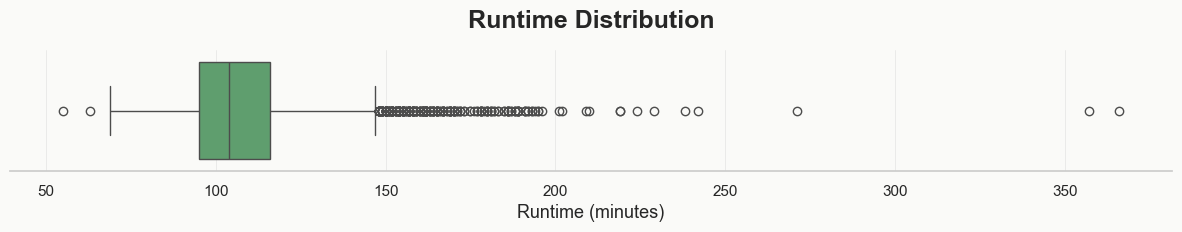

In [65]:
# Exploratory Data Analysis (EDA)/ Data Visualization

fig, ax = plt.subplots(figsize=(12,2.5))

sns.boxplot(
    data=df,
    x='runtime',
    color='#55A868'
)

ax.set_title("Runtime Distribution", fontsize=18, weight='bold')
ax.set_xlabel("Runtime (minutes)")

sns.despine(left=True)
plt.tight_layout()
plt.show()

### Insight — Runtime Distribution
Most films cluster tightly around [FILL: ~100–120] minutes, with a long tail of outliers 
stretching past [FILL: ~200] minutes. A handful of these long-runtime outliers are worth 
a manual check to confirm they're real (e.g. director's cuts) rather than data entry errors.

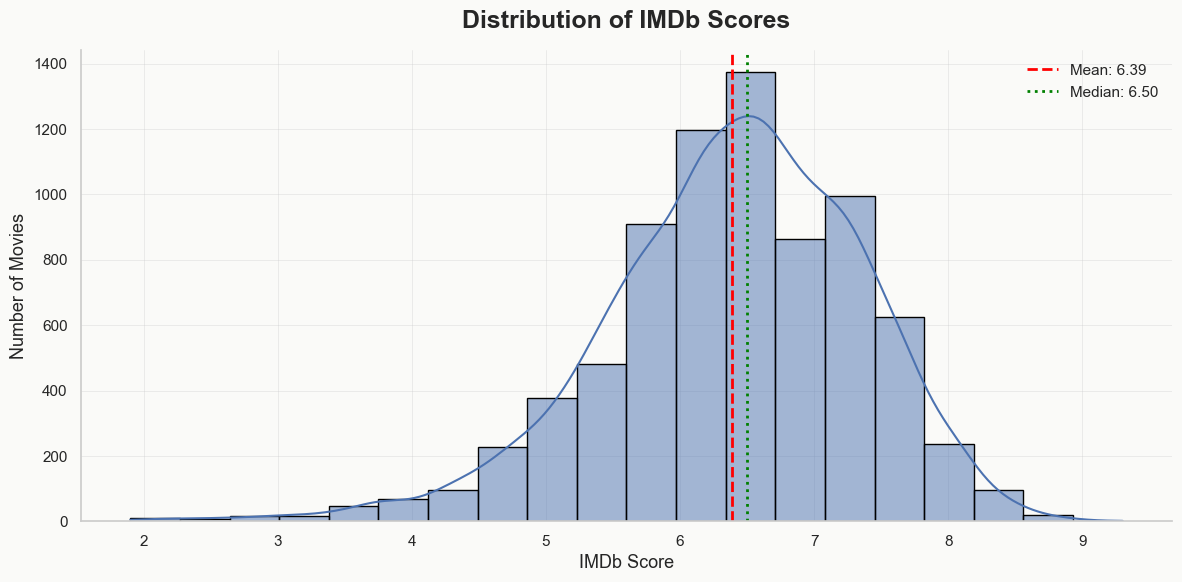

In [45]:
# Distribution of Movies Rating Over the years
fig, ax = plt.subplots(figsize=(12,6))
sns.histplot(
    data=df,
    x='score',
    bins=20,
    kde=True,
    edgecolor='black',
    color='#4C72B0'
)

ax.axvline(df['score'].mean(),
           color='red',
           linestyle='--',
           linewidth=2,
           label=f"Mean: {df['score'].mean():.2f}")

ax.axvline(df['score'].median(),
           color='green',
           linestyle=':',
           linewidth=2,
           label=f"Median: {df['score'].median():.2f}")

ax.set_title("Distribution of IMDb Scores", fontsize=18, weight='bold')
ax.set_xlabel("IMDb Score")
ax.set_ylabel("Number of Movies")

plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

### Insight — IMDb Score Distribution
Scores are roughly bell-shaped and centered around [FILL: mean value shown by the red line], 
slightly [FILL: left/right]-skewed — meaning most films land in the "decent but unremarkable" 
range, and very few films score below 3 or above 9.

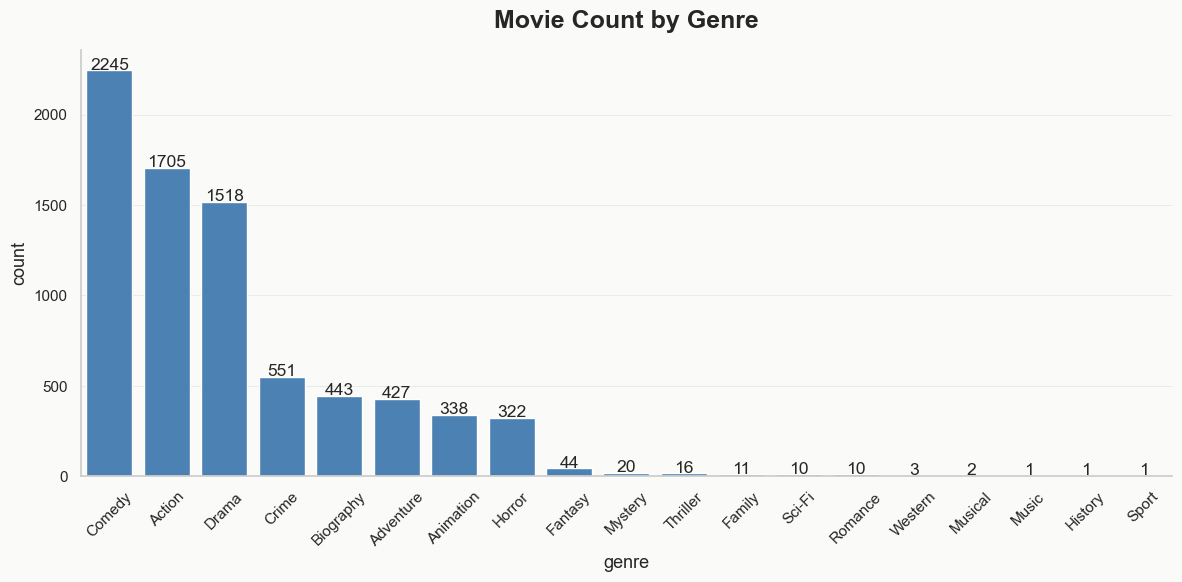

In [46]:
genre = (
    df['genre']
    .value_counts()
    .reset_index()
)

genre.columns = ['genre', 'count']

plt.figure(figsize=(12,6))

sns.barplot(
    data=genre,
    x='genre',
    y='count'
)

plt.title('Movie Count by Genre', fontsize=18, weight='bold')
plt.xticks(rotation=45)

for i, v in enumerate(genre['count']):
    plt.text(i, v+5, str(v), ha='center')

sns.despine()
plt.tight_layout()
plt.show()

### Insight — Genre Volume
[FILL: e.g. "Comedy and Action dominate the dataset by volume"], which matters for later 
comparisons — genres with few films (e.g. Western, Sport) will have noisier averages and 
should be read with caution.

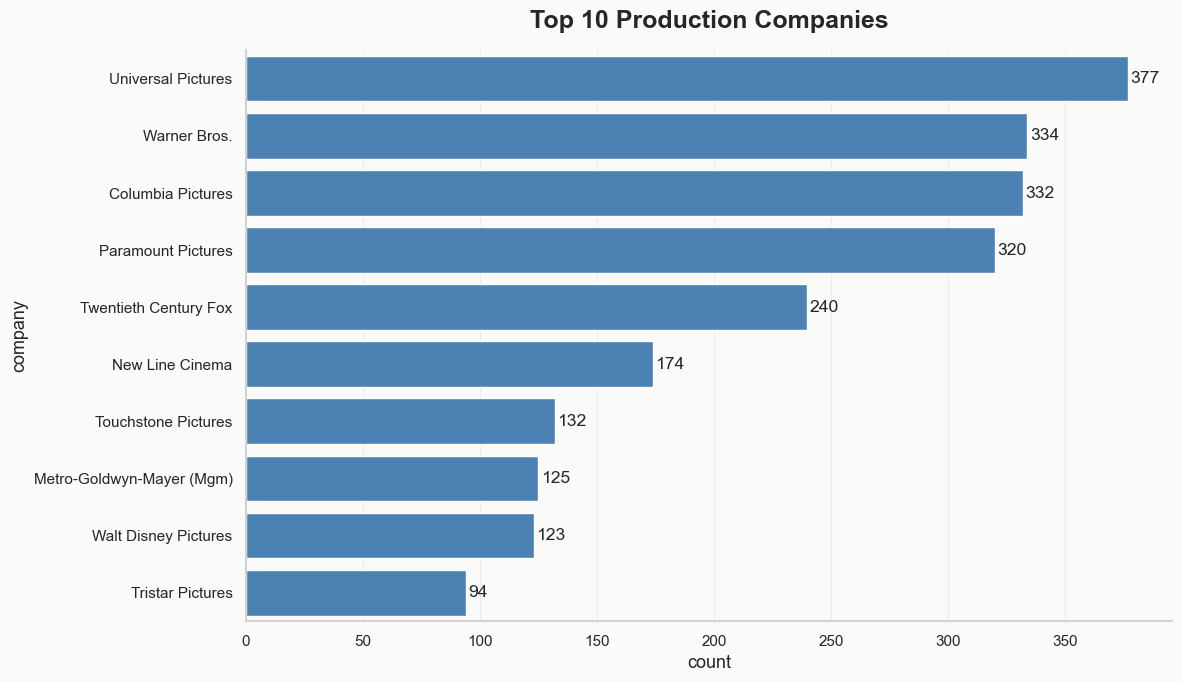

In [47]:
company = (
    df['company']
    .value_counts()
    .head(10)
    .reset_index()
)

company.columns=['company','count']

plt.figure(figsize=(12,7))

sns.barplot(
    data=company,
    x='count',
    y='company'
)

plt.title('Top 10 Production Companies',
          fontsize=18,
          weight='bold')

for i,v in enumerate(company['count']):
    plt.text(v+1,i,str(v),va='center')

sns.despine()
plt.tight_layout()
plt.show()

### Insight — Most Prolific Studios
The major legacy studios (Warner Bros., Universal, Columbia, Paramount) lead in raw film 
count, unsurprising given they've operated across the full 1980–2020 window. This is 
volume, not performance — I look at gross and ROI by studio separately in the KPI section.

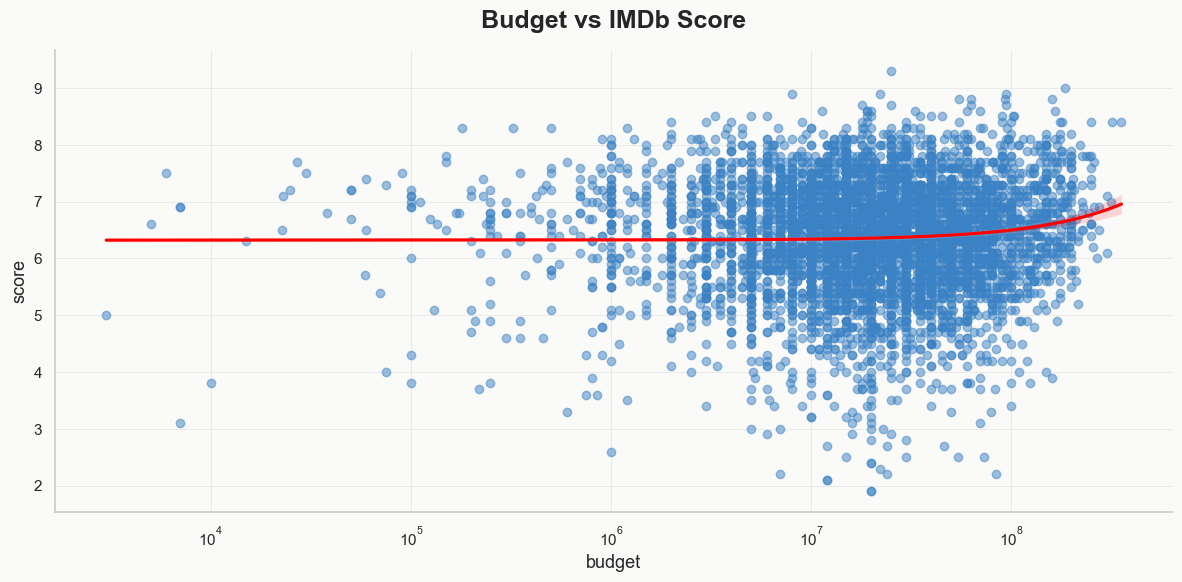

In [48]:
plt.figure(figsize=(12,6))

sns.regplot(
    data=df,
    x='budget',
    y='score',
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)

plt.xscale('log')

plt.title('Budget vs IMDb Score', fontsize=18, weight='bold')

sns.despine()
plt.tight_layout()
plt.show()

### Insight — Budget vs Quality
There's only a weak relationship between how much a film costs and how well it's rated — 
the regression line is close to flat. Bigger budgets buy production value, not necessarily 
audience approval.

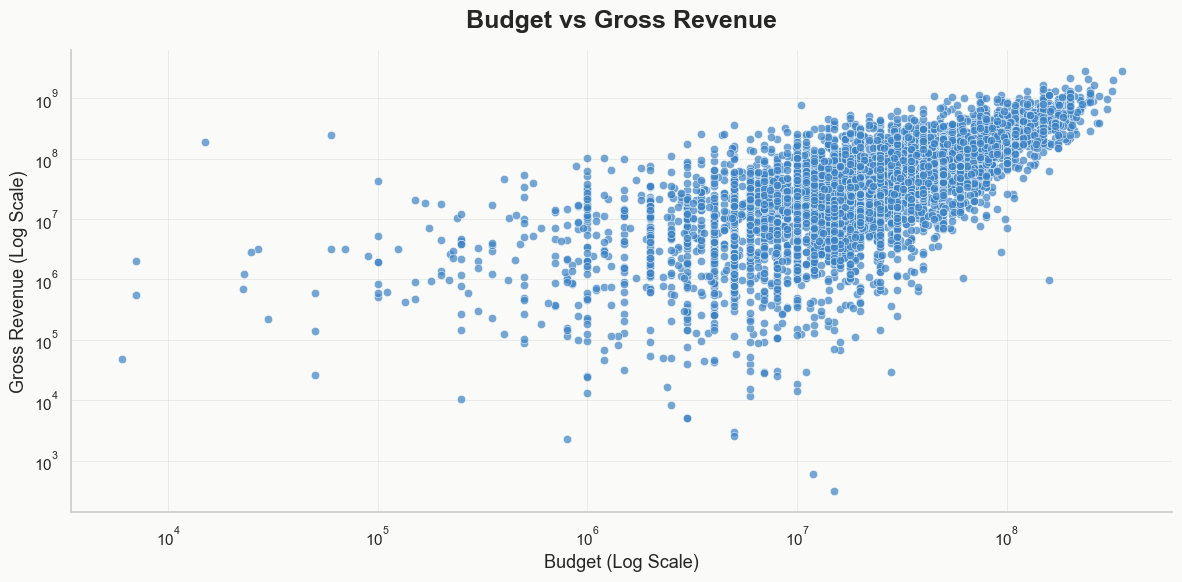

In [49]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df,
    x='budget',
    y='gross',
    alpha=0.7
)

plt.xscale('log')
plt.yscale('log')

plt.title('Budget vs Gross Revenue', fontsize=18, weight='bold')
plt.xlabel('Budget (Log Scale)')
plt.ylabel('Gross Revenue (Log Scale)')

sns.despine()
plt.tight_layout()
plt.show()

### Insight — Budget vs Revenue
Unlike score, gross revenue shows a much clearer positive relationship with budget on the 
log-log scale — bigger budgets do tend to earn more in absolute terms, though with wide 
variance (plenty of high-budget films underperform, and some micro-budget films earn a lot).

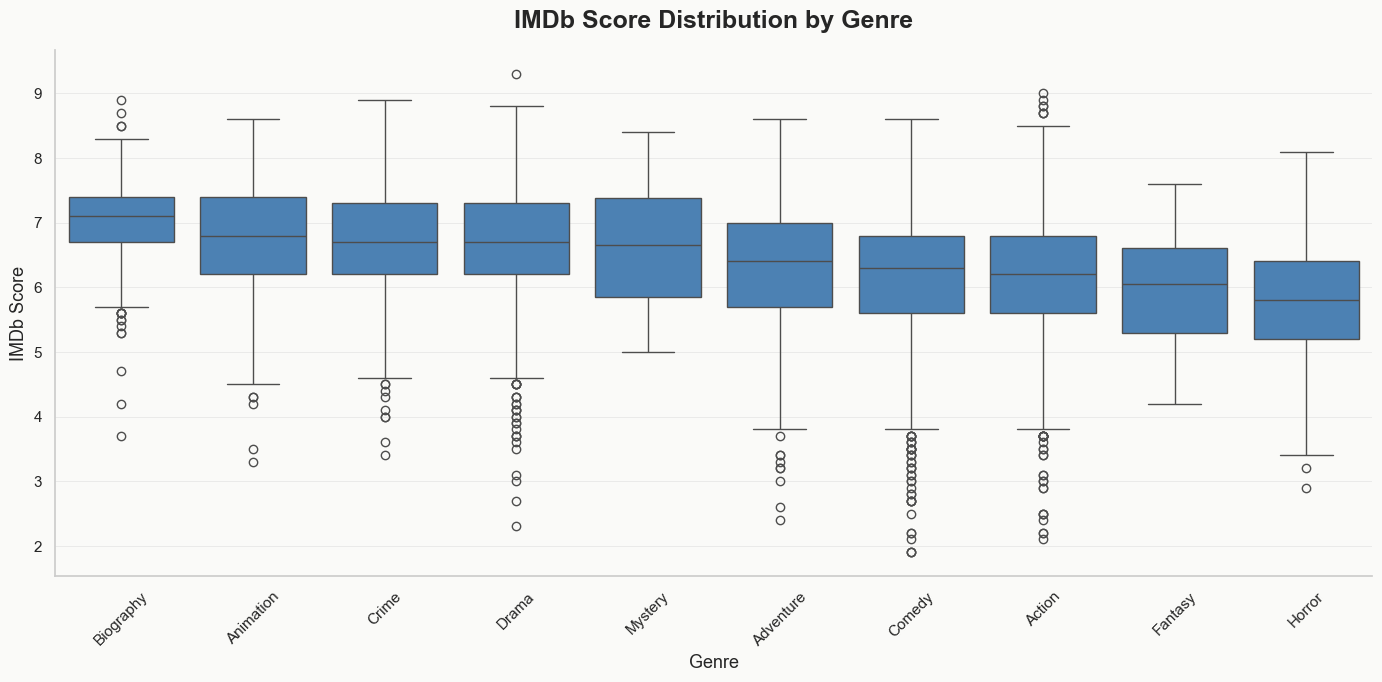

In [50]:
top_genres = df['genre'].value_counts().head(10).index

df_genre = df[df['genre'].isin(top_genres)]
order = (
    df_genre.groupby('genre')['score']
    .median()
    .sort_values(ascending=False)
    .index
)
plt.figure(figsize=(14,7))

sns.boxplot(
    data=df_genre,
    x='genre',
    y='score',
    order=order
)
plt.title('IMDb Score Distribution by Genre',
          fontsize=18,
          weight='bold')

plt.xlabel('Genre')
plt.ylabel('IMDb Score')
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()

### Insight — Quality by Genre
[FILL: name the top 1-2 genres by median score] score highest and most consistently, 
while [FILL: name a genre with a wide box/whiskers] shows the widest spread — meaning it's 
the most hit-or-miss genre for audience reception.

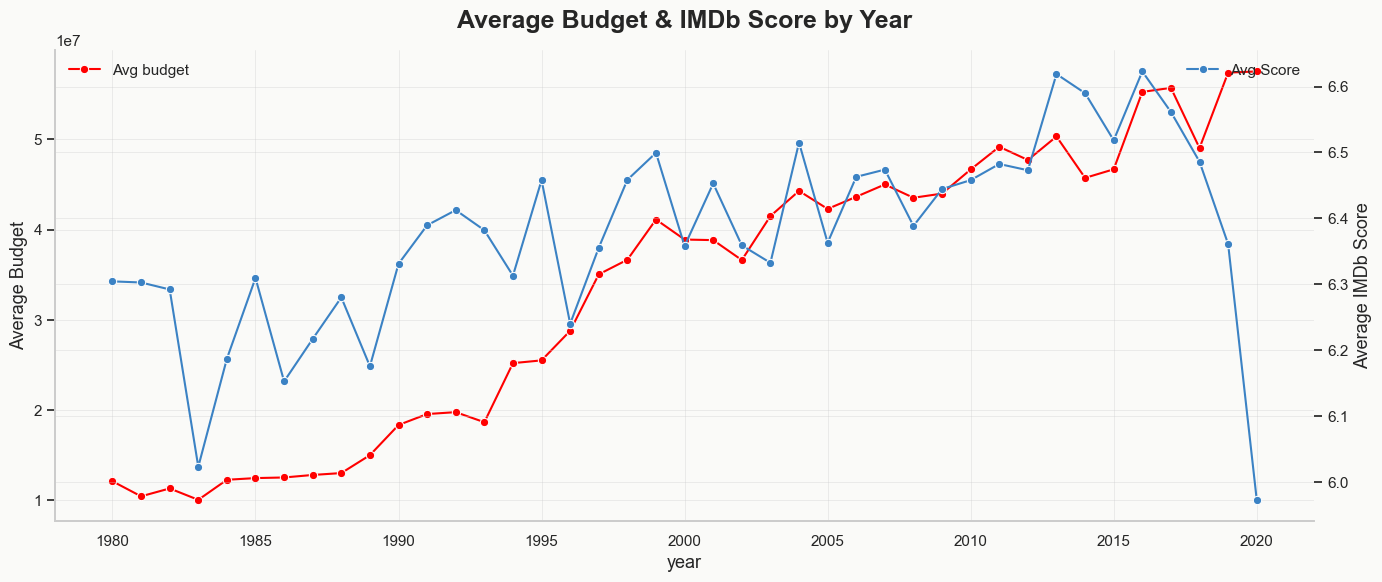

In [51]:
yearly = (
    df.groupby('year')
    .agg(
        avg_budget=('budget', 'mean'),
        avg_score=('score', 'mean')
    )
    .reset_index()
)
fig, ax1 = plt.subplots(figsize=(14,6))

sns.lineplot(
    data=yearly,
    x='year',
    y='avg_budget',
    ax=ax1,
    marker='o',color='red',label='Avg budget'
)

ax1.set_ylabel('Average Budget')

ax2 = ax1.twinx()

sns.lineplot(
    data=yearly,
    x='year',
    y='avg_score',
    ax=ax2,
    marker='o',label='Avg Score'
)

ax2.set_ylabel('Average IMDb Score')

ax1.set_title('Average Budget & IMDb Score by Year')

plt.tight_layout()

plt.show()

### Insight — Budgets vs Scores Over Time
Average budgets have risen sharply since 1980, largely driven by blockbuster-era spending 
increases. Average scores, by contrast, have stayed comparatively flat — reinforcing the 
budget-vs-score finding above: the industry is spending more without a proportional 
quality payoff.

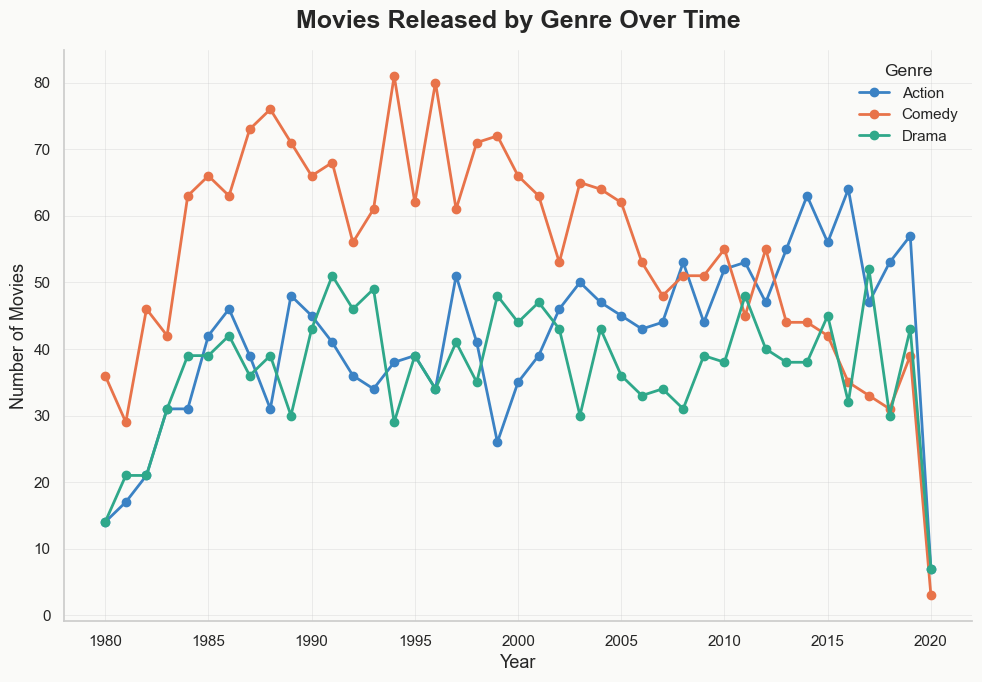

In [52]:
top_genres = df['genre'].value_counts().head(3).index

df_genre = df[df['genre'].isin(top_genres)]
genre_year = (
    df_genre
    .groupby(['year', 'genre'])
    .size()
    .unstack(fill_value=0)
)
plt.figure(figsize=(10,7))

for genre in genre_year.columns:
    plt.plot(
        genre_year.index,
        genre_year[genre],
        marker='o',
        linewidth=2,
        label=genre
    )

plt.title('Movies Released by Genre Over Time',
          fontsize=18,
          weight='bold')

plt.xlabel('Year')
plt.ylabel('Number of Movies')

plt.legend(title='Genre')

sns.despine()

plt.tight_layout()

plt.show()

### Insight — Genre Popularity Shift
[FILL: e.g. "Action releases have grown steadily since the 2000s, while Comedy's share has 
declined"] — reflecting the industry's shift toward big, franchise-driven releases.

In [53]:
# First KPI
#ROI bases kpis
df_genre=df.groupby('genre').agg(Avg_ROI=('ROI','mean'),Median_ROI=('ROI','median')).sort_values('Avg_ROI',ascending=False).head(10)
print(df_genre)


             Avg_ROI  Median_ROI
genre                           
Horror     75.756553    2.047218
Family     20.130188    3.446942
Thriller    3.299775    2.702238
Animation   2.991529    1.929611
Drama       2.718104    0.526437
Comedy      2.636618    0.787556
Adventure   2.128300    0.877967
Action      1.934869    0.872290
Mystery     1.804621    0.977233
Biography   1.712246    0.476405


### KPI — ROI by Genre
Horror is by far the most efficient genre (avg ROI ~76x, median ~2x — a few breakout hits 
skew the average heavily). Family films also stand out (avg ROI ~20x). Both make sense: 
horror and family films are typically made on low budgets but can draw large audiences, 
so even modest grosses translate into outsized returns.

In [54]:
# Second Kpi
df_genre=df.groupby('Decade').agg(Avg_ROI=('ROI','mean'),Median_ROI=('ROI','median')).sort_values('Avg_ROI',ascending=False).head(10)
print(df_genre)


          Avg_ROI  Median_ROI
Decade                       
2000    10.111867    0.880322
1990     4.935665    0.153557
2010     3.485220    1.544889
1980     2.605873    0.569869


### KPI — ROI by Decade
The 2000s show the highest average ROI (~10x), though the median (~0.88x) tells a more 
sober story — half of 2000s films with known budgets didn't even break even. The average 
is being pulled up by a small number of huge hits.

In [60]:
# KPI : Break-Even Rate
kpi3_df = df.dropna(subset=["budget", "gross"]).copy()

break_even_rate = kpi3_df["Is_Profitable"].value_counts(normalize=True) * 100
print(break_even_rate)

coverage_pct = len(kpi3_df) / len(df) * 100
print(f"\nBased on {len(kpi3_df):,} of {len(df):,} films "
      f"({coverage_pct:.1f}% of the dataset with known budget & gross)")




Is_Profitable
Yes    67.770419
No     32.229581
Name: proportion, dtype: float64

Based on 5,436 of 7,668 films (70.9% of the dataset with known budget & gross)


### KPI — Break-Even Rate
Among the 5,436 films with both budget and gross known (71% of the dataset), 67.8% grossed 
more than their budget and 32.2% did not. Roughly one in three films in this dataset lost 
money outright — a useful reality check against the "budget = success" assumption.

In [61]:
# Genere Summary
kpi5_df=df.dropna(subset=['genre','score']).copy()
genre_summary=kpi5_df.groupby('genre').agg(Avg_score=('score','mean'),Film_count=('score','count')).sort_values('Avg_score',ascending=False)
print(genre_summary)

           Avg_score  Film_count
genre                           
History     8.300000           1
Musical     8.050000           2
Music       7.200000           1
Biography   7.030926         443
Animation   6.769231         338
Drama       6.693668        1516
Crime       6.671506         551
Mystery     6.665000          20
Romance     6.410000          10
Family      6.363636          11
Adventure   6.291569         427
Sci-Fi      6.210000          10
Action      6.202817        1704
Comedy      6.193987        2245
Fantasy     6.006818          44
Thriller    5.912500          16
Sport       5.900000           1
Horror      5.750621         322
Western     5.666667           3


### KPI — Average Score by Genre
Biography (7.03 avg, 443 films) and Drama (6.69 avg, 1,516 films) score highest among genres 
with meaningful sample sizes. History, Musical, and Music genres show high averages but with 
only 1-2 films each — too small to trust. Horror scores lowest among high-volume genres (5.75).

In [62]:
#KPI : Votes-to-Score Correlation
kpi6_df=df.dropna(subset=["score", "votes"]).copy()
kpi6_df["log_votes"] = np.log10(kpi6_df["votes"].replace(0, np.nan))
raw_corr = kpi6_df[["votes", "score"]].corr().iloc[0,1]
log_corr = kpi6_df[["log_votes", "score"]].corr().iloc[0,1]
print(f"Correlation (raw votes vs score):  r = {raw_corr:.3f}")
print(f"Correlation (log votes vs score):  r = {log_corr:.3f}")


Correlation (raw votes vs score):  r = 0.409
Correlation (log votes vs score):  r = 0.427


### KPI — Buzz vs Quality
Votes and score have a moderate positive correlation (r = 0.41 raw, 0.43 on log-scaled 
votes) — popular films do tend to be rated somewhat higher, but the relationship is far 
from perfect. Plenty of heavily-voted films are mediocre, and plenty of well-rated films 
stay under the radar.

In [63]:
#KPI : Top 10 studios in terms of gross collection

kpi7_df=df.dropna(subset=["ROI", "company"]).copy()
top_gross_studios = (
    kpi7_df.groupby("company")["gross"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 studios by TOTAL GROSS:")
print(top_gross_studios)
top10_share = top_gross_studios.sum() / kpi7_df["gross"].sum() * 100
print(f"\nTop 10 studios account for {top10_share:.1f}% of total gross in the dataset")


Top 10 studios by TOTAL GROSS:
company
Warner Bros.             5.477320e+10
Universal Pictures       5.124111e+10
Columbia Pictures        4.235643e+10
Paramount Pictures       4.002170e+10
Twentieth Century Fox    3.954257e+10
Walt Disney Pictures     3.583365e+10
New Line Cinema          1.962879e+10
Marvel Studios           1.506559e+10
Dreamworks Animation     1.187361e+10
Dreamworks Pictures      1.159381e+10
Name: gross, dtype: float64

Top 10 studios account for 57.5% of total gross in the dataset


### KPI — Top Studios by Total Gross
Warner Bros. ($54.8B) and Universal ($51.2B) lead all studios in cumulative gross, with 
the top 10 studios accounting for 57.5% of all gross in the dataset — a reminder that a 
small number of major studios dominate box office revenue, even though smaller studios 
produce plenty of films (per the volume chart earlier).

In [64]:
# KPI :  Budget Efficiency Score by Genre
kpi8_df = df.dropna(subset=["score", "budget", "genre"]).copy()
genre_counts = kpi8_df["genre"].value_counts()
valid_genres = genre_counts[genre_counts >= 30].index
kpi8_df = kpi8_df[kpi8_df["genre"].isin(valid_genres)]
kpi8_df['Efficiency_score']=kpi8_df['score']/(kpi8_df['budget']/1000000)
efficiency_by_genre=kpi8_df.groupby('genre')['Efficiency_score'].median().sort_values(ascending=False)
print(efficiency_by_genre)


genre
Horror       0.686111
Fantasy      0.647426
Drama        0.428571
Crime        0.413333
Comedy       0.354444
Biography    0.348000
Adventure    0.241667
Action       0.155000
Animation    0.093333
Name: Efficiency_score, dtype: float64


### KPI — Score per Dollar of Budget
Horror (0.69) and Fantasy (0.65) deliver the most IMDb score per million dollars spent, 
while Animation (0.09) is the least efficient — animated films tend to have very high 
budgets relative to the score they achieve, likely due to production costs unrelated to 
audience reception.

## Conclusion

**Question**:Does money buy movie success?

**Answer**: Not really — budget predicts revenue reasonably well, but barely predicts quality.

**Key findings:**
1. Budget and IMDb score are only weakly related — bigger budgets buy scale, not approval.
2. Budget and gross revenue are strongly related, but ~32% of films with known budgets 
   still lose money — high spending doesn't guarantee profitability.
3. Efficiency varies sharply by genre: Horror and Family films deliver the highest ROI 
   and score-per-dollar, while big-budget genres like Animation are the least efficient 
   by that measure.

**Limitations:** 28% of films are missing budget data, which skews financial KPIs toward 
better-documented (often bigger) releases. The dataset also has no marketing spend, 
inflation adjustment, or streaming-era release data, which limits how directly older 
and newer films can be compared.